# Dokumentacja projektu - Klasyfikacja owoców
Grupa: SliUM1 D
- Andrzej Małolepszy 103777
- Maciej Gońda 103614
- Patryk Kowalczyk 70192

Prowadzący przedmiot: Dr inż. Łukasz Jeleń

Kurs: Analiza Danych Multimedialnych Projekt; ADM_ŁJE_INF_NW_TR_HB+marc_Zima 2025/2026

Dataset: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

## Wstęp
Celem projektu było zaprojektowanie i implementacja systemu automatycznejklasyfikacji wybranych owoców (jabłek, bananów, ananasów) na podstawie ich obrazów. Założeniem pracy było wykorzystanie klasycznych metod przetwarzania obrazów, bez zastosowania uczenia głębokiego.

Proces klasyfikacji przedstawiony w rozwiązaniu można podzielić na 3 etapy:
1. Wstępne przetworzenie i segmentacja obrazów;
2. Ekstrakcja wybranych cech za pomocą tradycyjnych metod uczenia maszynowego (w tym z biblioteki OpenCV);
3. Finalna klasyfikacja na podstawie cech pobranych z obrazu.

Wpierw przedstawiono przykładowy proces klasyfikacji dla wybranego owocu (banan), a następnie rozwiązanie przeniesiono na pełen zbiór danych.

## Eksploracja danych

In [16]:
path = "../fruit-and-vegetable-image-recognition/versions/8"

### Liczebność klas

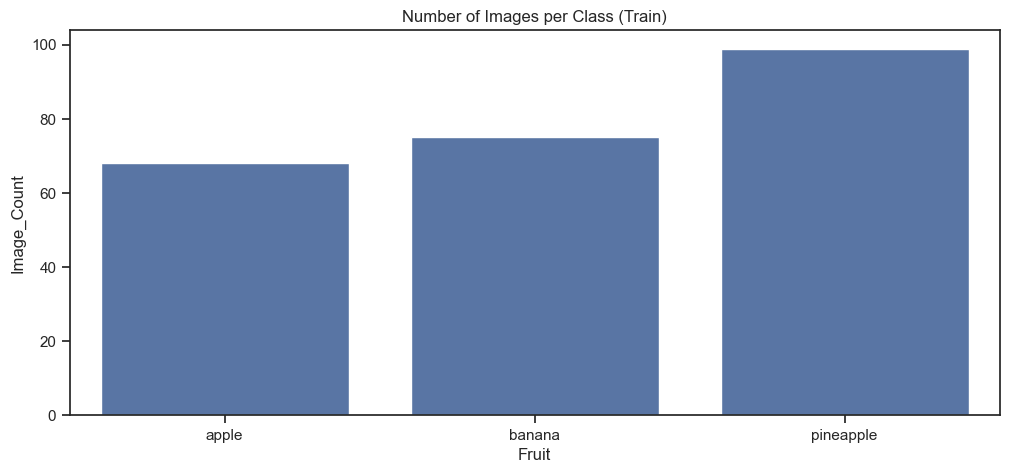

In [17]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import os

fruits = ["apple", "banana", "pineapple"]
image_count = {}

for fruit in fruits:
    fruit_path = os.path.join(path + '/train', fruit)
    image_count[fruit] = len(os.listdir(fruit_path))

df = pd.DataFrame(image_count.items(), columns=["Fruit", "Image_Count"])

plt.figure(figsize=(12,5))
seaborn.barplot(x="Fruit", y="Image_Count", data=df)
plt.title("Number of Images per Class (Train)")
plt.show()

### Przykładowy owoc

In [18]:
import cv2

def BGR2RGB(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

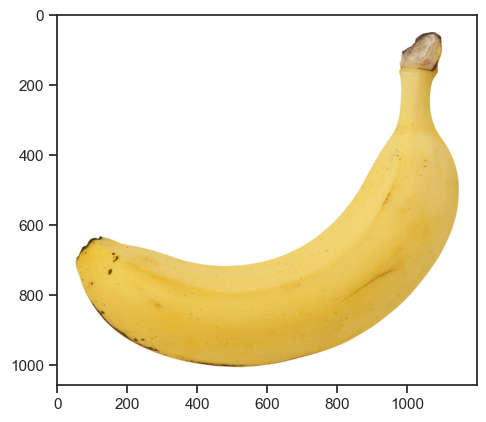

In [19]:
import matplotlib.pyplot as plt

image_path = os.path.join(path + '/train/banana/Image_3.jpg')

img = cv2.imread(image_path)
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

#### Histogram kanałów BGR

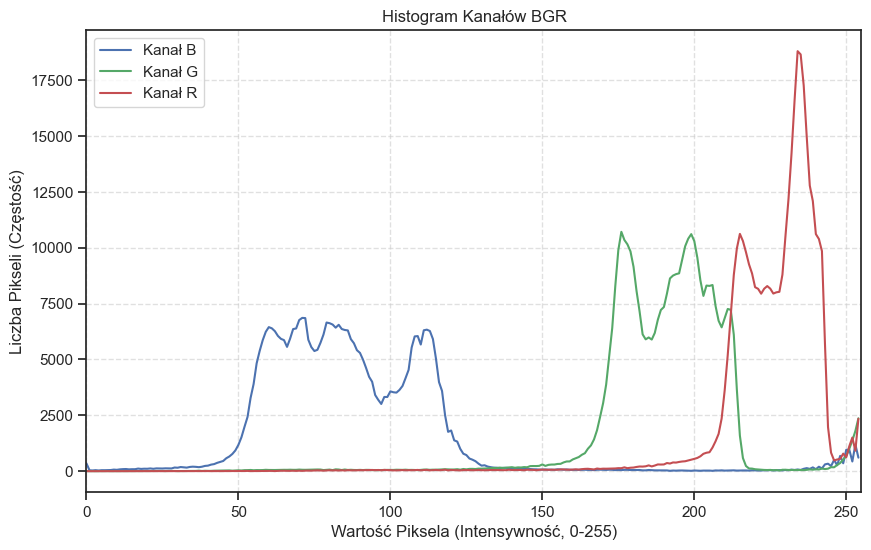

In [20]:
import cv2
import matplotlib.pyplot as plt

colors = ('b', 'g', 'r')
plt.figure(figsize=(10, 6))
plt.title('Histogram Kanałów BGR')
plt.xlabel('Wartość Piksela (Intensywność, 0-255)')
plt.ylabel('Liczba Pikseli (Częstość)')

for i, col in enumerate(colors):
  # Obliczenie histogramu dla pojedynczego kanału
  # [img]: obraz wejściowy
  # [i]: indeks kanału (0, 1 lub 2)
  # None: brak maski
  # [255]: liczba binow
  # [0, 255]: zakres wartości - bez 256, zeby wyciac bialy
  hist = cv2.calcHist([img], [i], None, [255], [0, 255])

  # Wyświetlenie histogramu
  plt.plot(hist, color=col, label=f'Kanał {col.upper()}')
  plt.xlim([0, 255])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Segmentacja

### Odszumianie - filtr medianowy
Zastępuje każdy piksel medianą wartości pikseli z jego otoczenia (5x5).
-> pozbywa sie małych niedoskonałości na owocach, jak ciemne kropki na bananie.

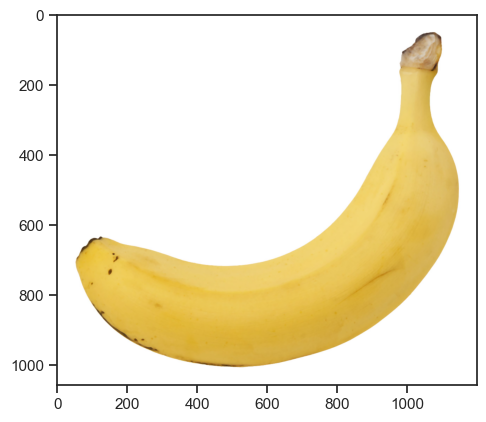

In [21]:
blurred_img = cv2.medianBlur(img, 5)
plt.imshow(BGR2RGB(blurred_img))

### konwersja dziedziny kolorów na HSV
Hue, Saturation, Value - reprezentacja kolorów niosąca więcej informacji przy przetwarzaniu ubrazów, bardziej odporna na zmianę oświetlenia (wówczas zmienia się głównie parametr V, H zostaje takie samo).

In [22]:
# konwersja na HSV
hsv_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)

#### Histogram wartości HSV

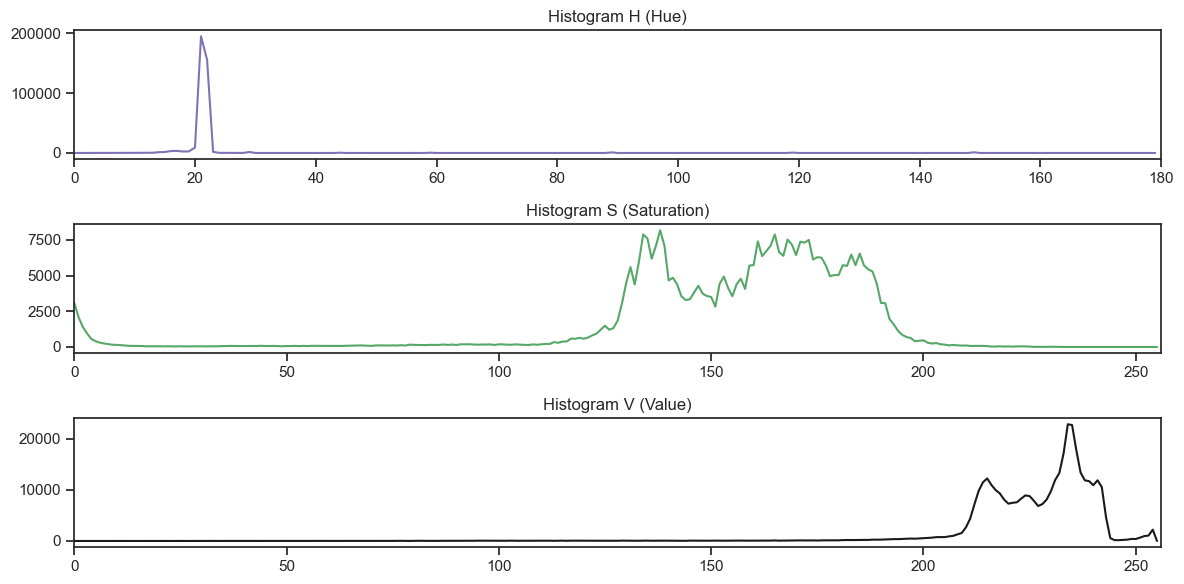

In [23]:
import cv2
import matplotlib.pyplot as plt

# Rozdzielenie kanałów
h, s, v = cv2.split(hsv_img)

# Obliczenie histogramów dla każdego kanału
hist_h = cv2.calcHist([hsv_img], [0], None, [180], [1, 180])  # H: 0–179 bez 1 (bo bialy)
hist_s = cv2.calcHist([hsv_img], [1], None, [256], [1, 256])  # S: 0–255 bez 1 (bo bialy)
hist_v = cv2.calcHist([hsv_img], [2], None, [256], [0, 255])  # V: 0–255 bez 256 (bo bialy)

# Wyświetlenie obrazu i histogramów
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.title('Histogram H (Hue)')
plt.plot(hist_h, color='m')
plt.xlim([0, 180])

plt.subplot(3, 1, 2)
plt.title('Histogram S (Saturation)')
plt.plot(hist_s, color='g')
plt.xlim([0, 256])

plt.subplot(3, 1, 3)
plt.title('Histogram V (Value)')
plt.plot(hist_v, color='k')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

### Maska
Progowanie na podstawie koloru - przyjmujemy, że owoc jest nasycony i dość jasny.

In [24]:
import numpy as np

lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność

In [25]:
def show_hsv_color(color):
  rect = np.zeros((50, 50, 3), dtype=np.uint8)
  rect[:] = color
  rect_bgr = cv2.cvtColor(rect, cv2.COLOR_HSV2BGR)
  plt.imshow(rect_bgr)
  plt.axis('off')
  plt.show()

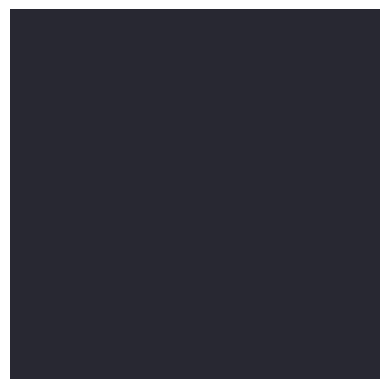

In [26]:
show_hsv_color(lower_bound)

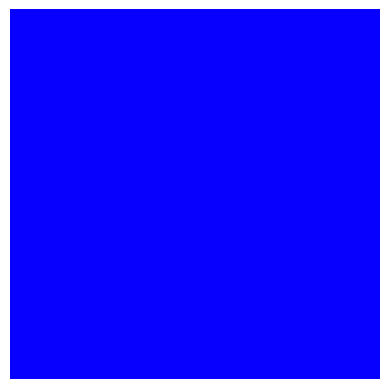

In [27]:
show_hsv_color(upper_bound)

In [28]:
mask = cv2.inRange(hsv_img, lower_bound, upper_bound)

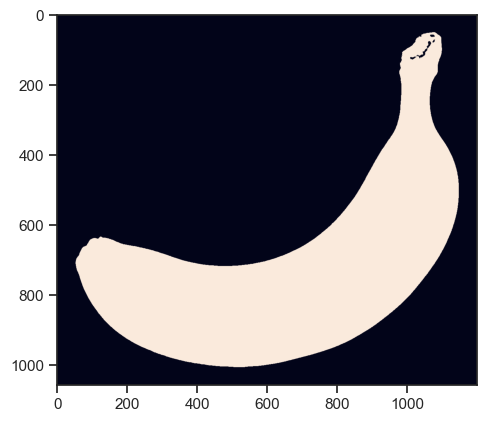

In [29]:
plt.imshow(mask)

### Operacje morfologiczne
Zamknięcie - usunięcie dziur + wygładzenie maski

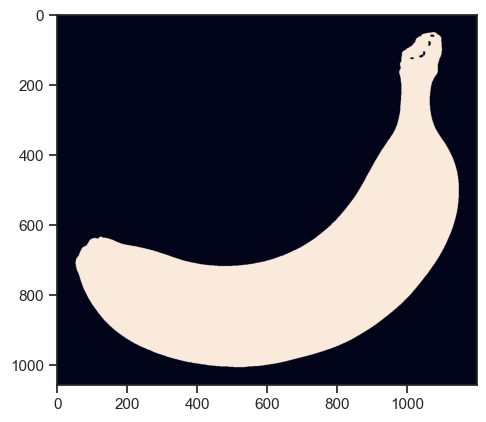

In [30]:
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(mask)

### Znalezienie największego konturu

In [31]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

In [32]:
# Stworzenie maski tylko dla największego konturu
object_mask = np.zeros_like(mask)
# -1 - indeks konturu - wszystkie z listy rysujemy
# 255 - kolor
# -1 grubośc lini - kontur wypełniony
cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1057, 1200), dtype=uint8)

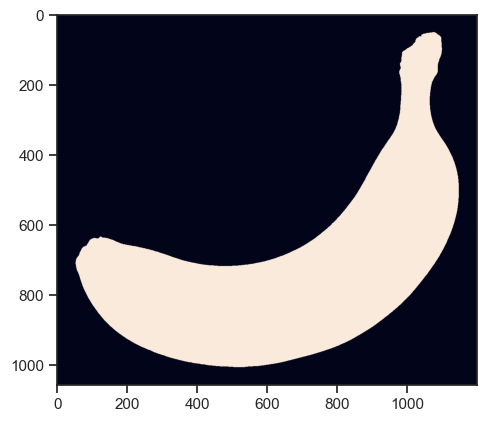

In [33]:
plt.imshow(object_mask)

### Nałożenie maski na owoc

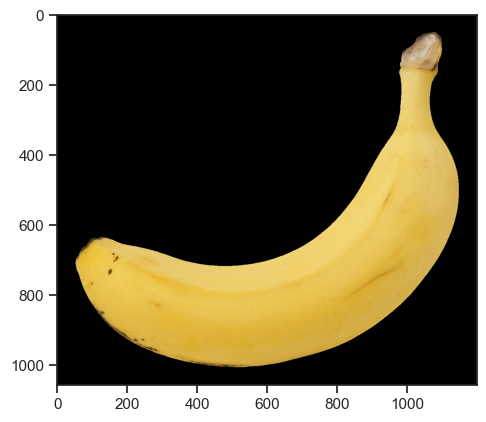

In [34]:
fruit_only = cv2.bitwise_and(blurred_img, blurred_img, mask=object_mask)
plt.imshow(BGR2RGB(fruit_only))

## Ekstrakcja cech

Cechy:
- średnie H
- średnie S
- średnie V
- odchylenie standardowe H
- odchylenie standardowe S
- odchylenie standardowe V
- współczynnik proporcji owocu
- eccentricity
- solidity
- convexity

### Ekstrakcja cech kolorów

In [35]:
hsv_img = cv2.cvtColor(fruit_only, cv2.COLOR_BGR2HSV)
h_channel = hsv_img[:, :, 0]
s_channel = hsv_img[:, :, 1]
v_channel = hsv_img[:, :, 2]

In [36]:
color_features = []

In [37]:
# Średnia
color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
# Odchylenie standardowe
color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

In [38]:
color_features

[np.float64(6.587128666035951),
 np.float64(47.306629612109745),
 np.float64(66.95865263323873),
 np.float64(10.169442150885326),
 np.float64(73.93952598921372),
 np.float64(103.50707793832866)]

### Aspect ratio

In [39]:
x, y, w, h = cv2.boundingRect(largest_contour)
aspect_ratio = w / h if h != 0 else 0
aspect_ratio

1.1442006269592477

### Eccentricity, Solidity

In [40]:
from skimage.measure import label, regionprops
# eccentricity
labeled_img = label(object_mask)
region = regionprops(labeled_img)[0]
eccentricity = region.eccentricity

# solidity
solidity = region.solidity

### Convexity

In [41]:
perimeter = cv2.arcLength(largest_contour, True)
convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
convexity = convex_hull_perimeter / perimeter

## Analiza zbioru

### Ramka

In [42]:
import pandas as pd
column_labels = [
    'Class', 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]


### Funkcja wykonująca powyższą segmentację oraz ekstrahująca cechy z obrazu

In [43]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops

def extract_features(df_features, image_path, fruit):
  image = cv2.imread(image_path)
  if image is None:
    print("Failed to load image:", image_path)
    return

  # Odszumianie - filtr medianowy
  blurred_img = cv2.medianBlur(image, 5)

  # konwersja na HSV
  hsv_image = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)

  # maska
  lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
  upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność
  mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

  # Operacje morfologiczne - zamknięcie
  kernel = np.ones((5,5), np.uint8)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

  # znalezienie kontur
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  largest_contour = max(contours, key=cv2.contourArea)

  # Stworzenie maski tylko dla największego konturu
  object_mask = np.zeros_like(mask)
  cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)
  
  # zamaskowanie obrazu
  fruit_only = cv2.bitwise_and(blurred_img, blurred_img, mask=object_mask)
  hsv_image = cv2.cvtColor(fruit_only, cv2.COLOR_BGR2HSV)

  h_channel = hsv_image[:, :, 0]
  s_channel = hsv_image[:, :, 1]
  v_channel = hsv_image[:, :, 2]
  
  color_features = []

  # Średnia
  color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
  # Odchylenie standardowe
  color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

  # aspect ratio
  x, y, w, h = cv2.boundingRect(largest_contour)
  aspect_ratio = w / h if h != 0 else 0

  # eccentricity
  labeled_img = label(object_mask)
  region = regionprops(labeled_img)[0]
  eccentricity = region.eccentricity

  # solidity
  solidity = region.solidity

  # convexity
  perimeter = cv2.arcLength(largest_contour, True)
  convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
  convexity = convex_hull_perimeter / perimeter

  # Wektor cech
  feature_vector = np.array([fruit] + color_features + [aspect_ratio, eccentricity, solidity, convexity])

  df_features.loc[len(df_features)] = feature_vector

### Rozpatrywane klasy

In [44]:
fruits = ["apple", "banana", "pineapple"]

### Zbiór treningowy

In [45]:
df_train = pd.DataFrame(columns=column_labels)
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [46]:
import os

dirpath = path + '/train'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_train, dirpath + '/' + fruit + '/' + filename, fruit)

In [47]:
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,4.545751388888889,50.728633333333335,43.00078888888889,15.166944773251437,78.94257677696987,67.96280036976017,1.0598885793871866,0.30357095756732944,0.9900985808193932,0.9017659072892173
2,apple,28.63712449799197,60.662955823293174,70.3066827309237,63.74565776285501,83.9971303273569,92.64228913874707,0.917098445595855,0.24272234677867274,0.9559078036500944,0.894251034019385
3,apple,55.11663541666667,112.59449583333334,111.37671875,45.64022038742705,64.9880178676871,50.66700596443473,1.5,0.7446844304347644,0.947715237217035,0.5407026911505509
4,apple,25.040821397569445,80.01944878472223,53.752367621527775,59.91586597295283,109.46884298276089,74.14852284091609,1.0491573033707866,0.547176329224612,0.8921280778568825,0.6859696444447613
...,...,...,...,...,...,...,...,...,...,...,...
237,pineapple,6.578227163461539,61.04520783253205,37.56498798076923,13.13538437268847,87.28367376291374,59.69190161411471,0.588495575221239,0.7756224625595297,0.8597771338694729,0.5598688366963397
238,pineapple,18.08968608583225,80.47936332594591,87.9405570017091,15.844442985875137,72.66108080500713,77.31715073408368,1.5,0.7716479500405204,0.752741626036064,0.2711994939618817
239,pineapple,10.795980092592593,71.61474583333333,65.25665555555555,13.739601133341074,81.59945304978075,77.64460738327926,0.7357449417535254,0.6251668187056554,0.6903964552602762,0.41357081825543024
240,pineapple,11.118292647559171,38.700738582789675,55.41799205783885,19.523908955424144,61.7650835708954,85.19399104605888,0.4050867441468755,0.9452102807121477,0.7224509039417144,0.35502840547560455


### Zbiór testowy

In [48]:
df_test = pd.DataFrame(columns=column_labels)
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [49]:
dirpath = path + '/test'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_test, dirpath + '/' + fruit + '/' + filename, fruit)

In [50]:
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
2,apple,44.173747829861114,56.18214409722222,54.55312174479167,74.45165367742163,94.08688254812715,88.61069222016313,0.9226190476190477,0.6866873300843939,0.8715786989386182,0.6224610675467126
3,apple,46.9709405,43.523292,44.8135085,77.98752965728218,72.45564286846624,74.06006609111574,1.835575485799701,0.8815539484269913,0.8267072201292641,0.5495078477094937
4,apple,70.92785703943778,89.77043671565916,131.28755431063394,49.03185653021426,65.57189442520006,92.55618911401176,1.5,0.7279757426728325,0.7352330164973497,0.3354555128169366
5,apple,26.166629490150637,95.8314006373117,93.95147740440325,48.00942159877753,116.33209664129421,113.10218460983997,1.0868055555555556,0.3653842923522567,0.9154067296396405,0.9057693082805955
6,apple,94.62235625,120.29033489583334,102.66145104166667,88.46057404991078,98.84562304802589,92.14360770478224,0.9577015163607342,0.3922917659893152,0.9637515631099437,0.8336846286074336
7,apple,6.512612383327233,166.17280151903367,100.02938409361273,9.290888445591397,104.54200824168953,76.53814504094812,1.499267935578331,0.809152052730126,0.7395437751647145,0.49291583795020877
8,apple,54.748760236105916,110.17793053996758,117.54776780147151,61.911092272266536,69.84261719832328,84.86965879010968,1.4666666666666666,0.641636363184252,0.8476097543725488,0.4713801842733973
9,apple,12.236221788194445,118.01075086805555,111.9316796875,20.295905669380545,69.47598065127998,69.9483680821237,1.7777777777777777,0.8218613034021803,0.9024266115147643,0.6333851203034429


#### Normalizacja

W celu dalszego wyliczenia korelacji, dane rzutowane są na typ numeryczny (domyślnie string).

In [51]:
numeric_labels = [ 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]

for label in numeric_labels:
  df_train[label] = pd.to_numeric(df_train[label], errors='coerce')
  df_test[label] = pd.to_numeric(df_test[label], errors='coerce')

In [52]:
# odrzucenie kolumny 'Class'
X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

### Wizualizacja rozkładu cech

#### Cechy związane z kolorem

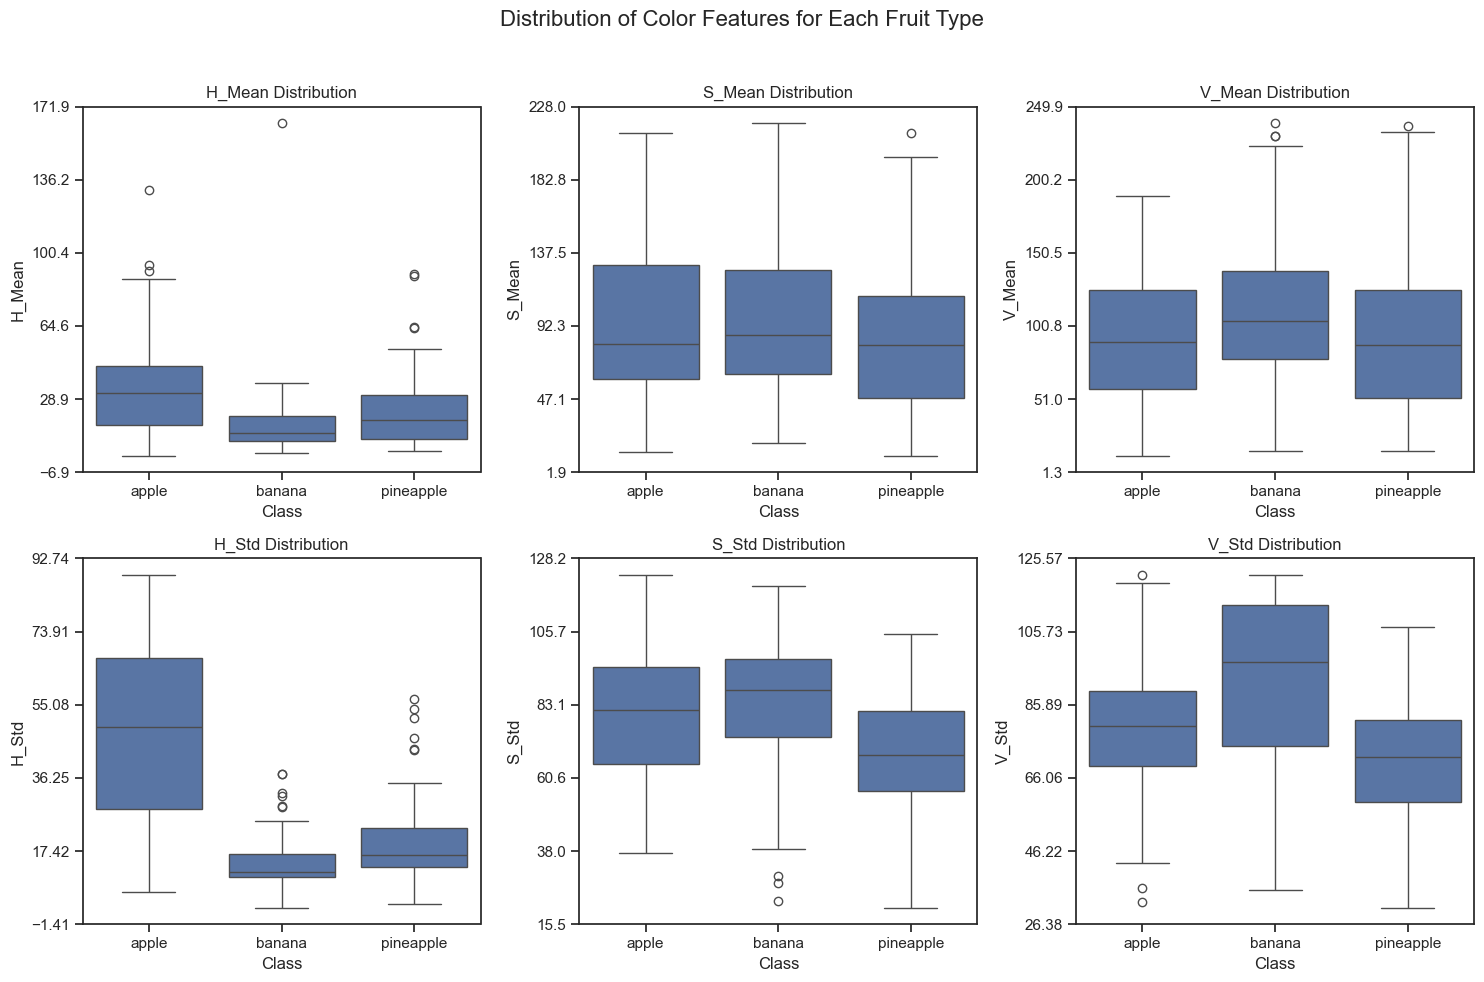

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

color_features = ['H_Mean', 'S_Mean', 'V_Mean', 'H_Std', 'S_Std', 'V_Std']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Color Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(color_features, 1):
    ax = plt.subplot(2, 3, i)
    
    sns.boxplot(x='Class', y=feature, data=df_train)
    plt.title(f'{feature} Distribution')
    
    # Force sorted y-ticks
    ymin, ymax = ax.get_ylim()
    num_ticks = 6
    ticks = np.linspace(ymin, ymax, num_ticks)
    ax.set_yticks(ticks)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Cechy związane ze kształtem

<Figure size 1500x500 with 0 Axes>

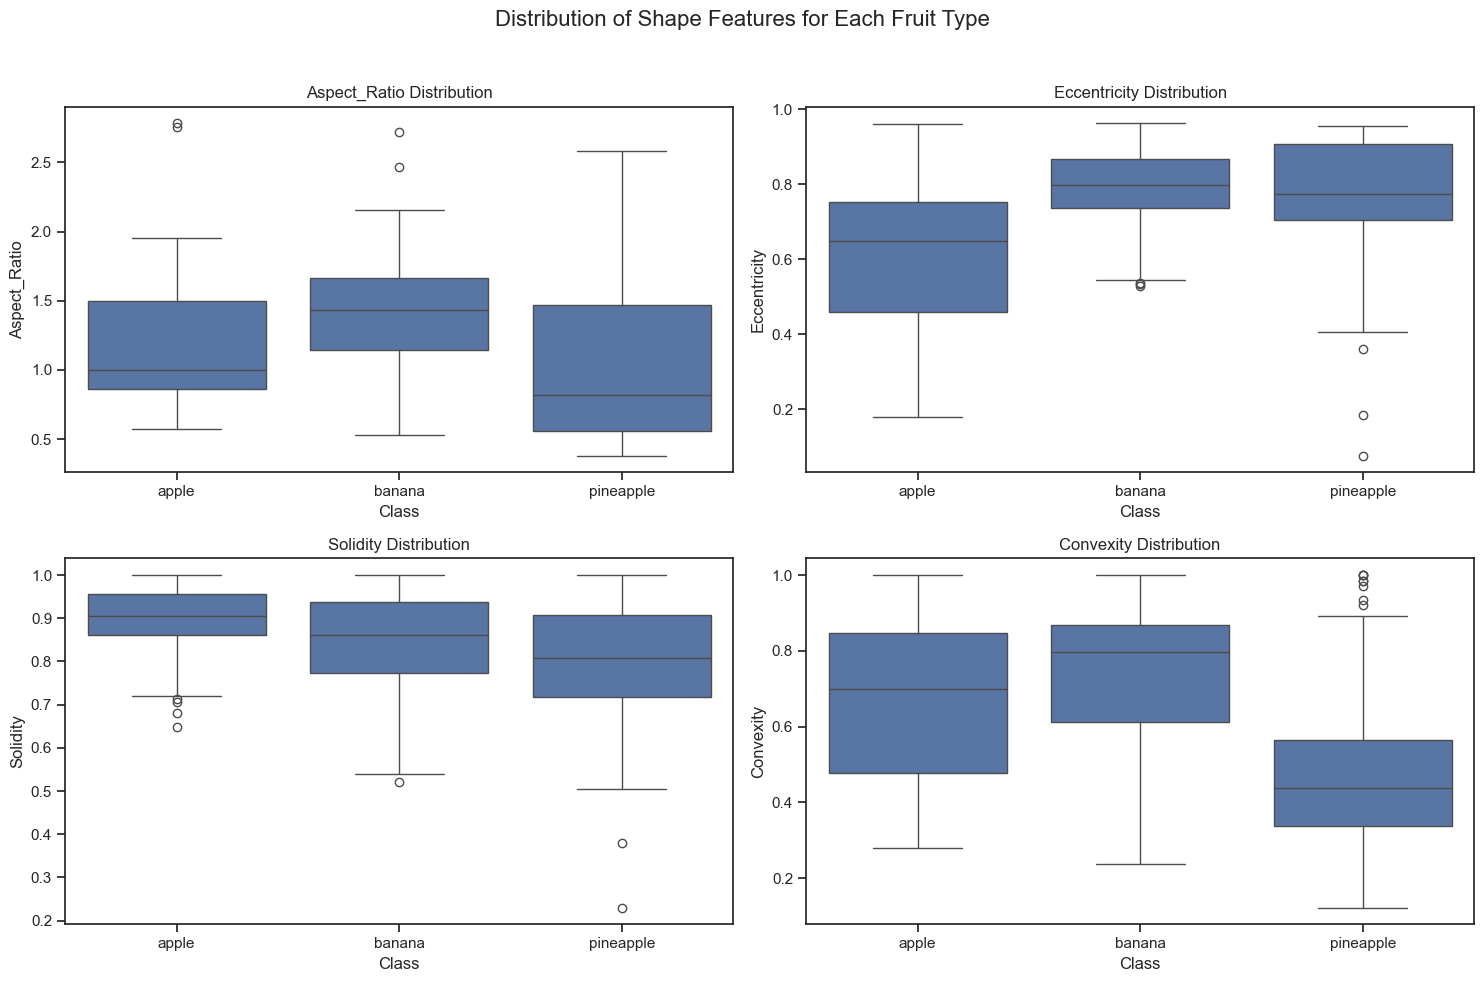

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

shape_features = ['Aspect_Ratio', 'Eccentricity', 'Solidity', 'Convexity']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(shape_features, 1):
  ax = plt.subplot(2, 2, i)
  
  sns.boxplot(x='Class', y=feature, data=df_train)
  plt.title(f'{feature} Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Macierz korelacji

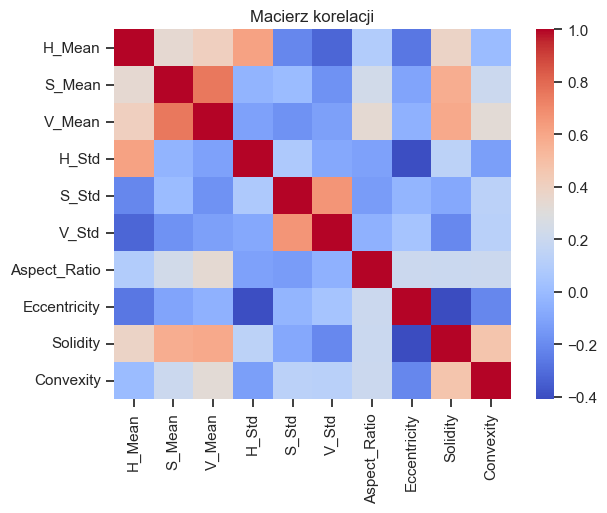

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = X_train.corr()
plt.figure()
sns.heatmap(correlation, cmap="coolwarm", annot=False)
plt.title("Macierz korelacji")
plt.show()

## Klasyfikacja

### Dobranie klasyfikatora
Na podstawie empirycznego testu, dobrano najlepszy klasyfikator - Drzewo Decyzyjne.

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Lista klasyfikatorów
classifiers = {
  'Random Forest': RandomForestClassifier(random_state=42),
  'SVM': SVC(random_state=42),
  'KNN': KNeighborsClassifier(),
  'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000),
  'Naive Bayes': GaussianNB(),
  'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Trenowanie i ewaluacja każdego
results = {}
for name, clf in classifiers.items():
  clf.fit(X_train, y_train)
  accuracy = clf.score(X_test, y_test)
  results[name] = accuracy
  print(f'{name} Accuracy: {accuracy:.4f}')

# Najlepszy
best_classifier_name = max(results, key=results.get)
print(f'\nNajlepszy klasyfikator: {best_classifier_name} accuracy {results[best_classifier_name]:.4f}')

Random Forest Accuracy: 0.8966
SVM Accuracy: 0.8621
KNN Accuracy: 0.8966
Logistic Regression Accuracy: 0.8276
Naive Bayes Accuracy: 0.8621
Decision Tree Accuracy: 0.9310

Najlepszy klasyfikator: Decision Tree accuracy 0.9310


### Confusion matrix

In [57]:
dtc = classifiers[best_classifier_name]
y_pred = dtc.predict(X_test)

Dokładność dtc: 0.931


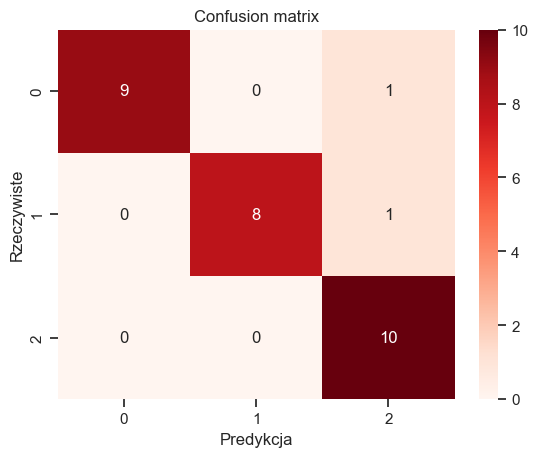

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Dokładność dtc: {dtc.score(X_test,y_test):.4}')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion matrix")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

### Feature ranking - najważniejsze cechy

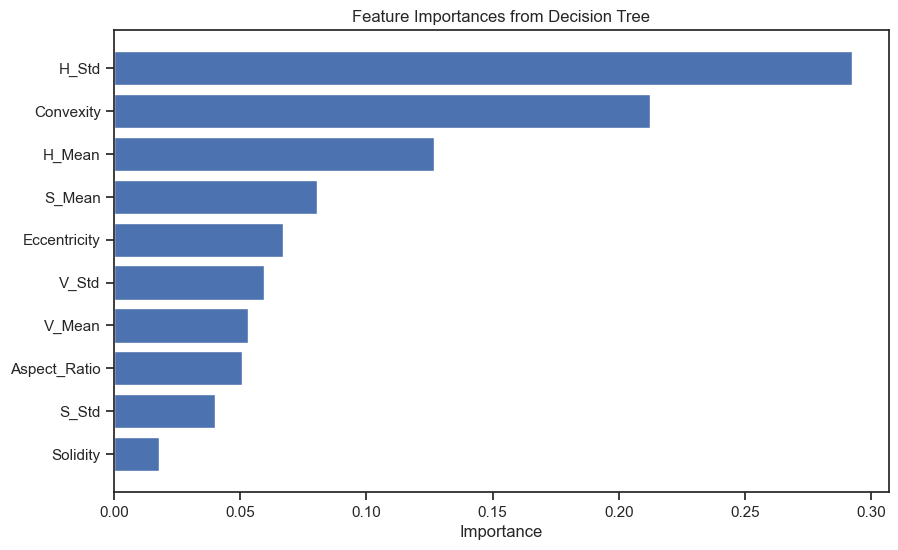

In [59]:
import matplotlib.pyplot as plt

# Najważniejsze cechy dla drzewa decyzyjnego
feature_importances = dtc.feature_importances_
features = X_train.columns

# Sortowanie cech po ich znaczeniu
sorted_idx = feature_importances.argsort()

# Wykres
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Importance')
plt.title('Feature Importances from Decision Tree')
plt.show()

## Dystrybucja cech dla owoców - Kernel Density Estimate

W celu sprawdzenia odchylenia standardowego poszczególnych owoców, zastosowano wykres KDE.

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_feature_distributions(df):
  # 1. Kopiujemy dane i określamy kolumnę docelową
  plot_df = df.copy()
  target_col = "Class"

  # 2. Konwersja cech na liczby i czyszczenie NaN
  feature_cols = [col for col in plot_df.columns if col != target_col]
  for col in feature_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

  # 3. Przygotowanie siatki wykresów
  sns.set_theme(style="whitegrid")
  num_cols = 3
  # Filtrujemy tylko te kolumny, które mają więcej niż jedną unikalną wartość (ważne dla KDE)
  valid_cols = [col for col in feature_cols if plot_df[col].nunique() > 1]

  num_rows = (len(valid_cols) + num_cols - 1) // num_cols
  fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))

  axes = axes.flatten()

  # 4. Rysowanie
  for i, col_name in enumerate(valid_cols):
    sns.kdeplot(
      data=plot_df,
      x=col_name,
      hue=target_col,
      fill=True,
      common_norm=False,
      palette="bright",
      alpha=0.3,
      ax=axes[i],
      warn_singular=False,  # Ignoruj ostrzeżenia o zerowej szerokości pasma
    )
    axes[i].set_title(f"Rozkład: {col_name}")

  # Usuwanie pustych wykresow
  for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()


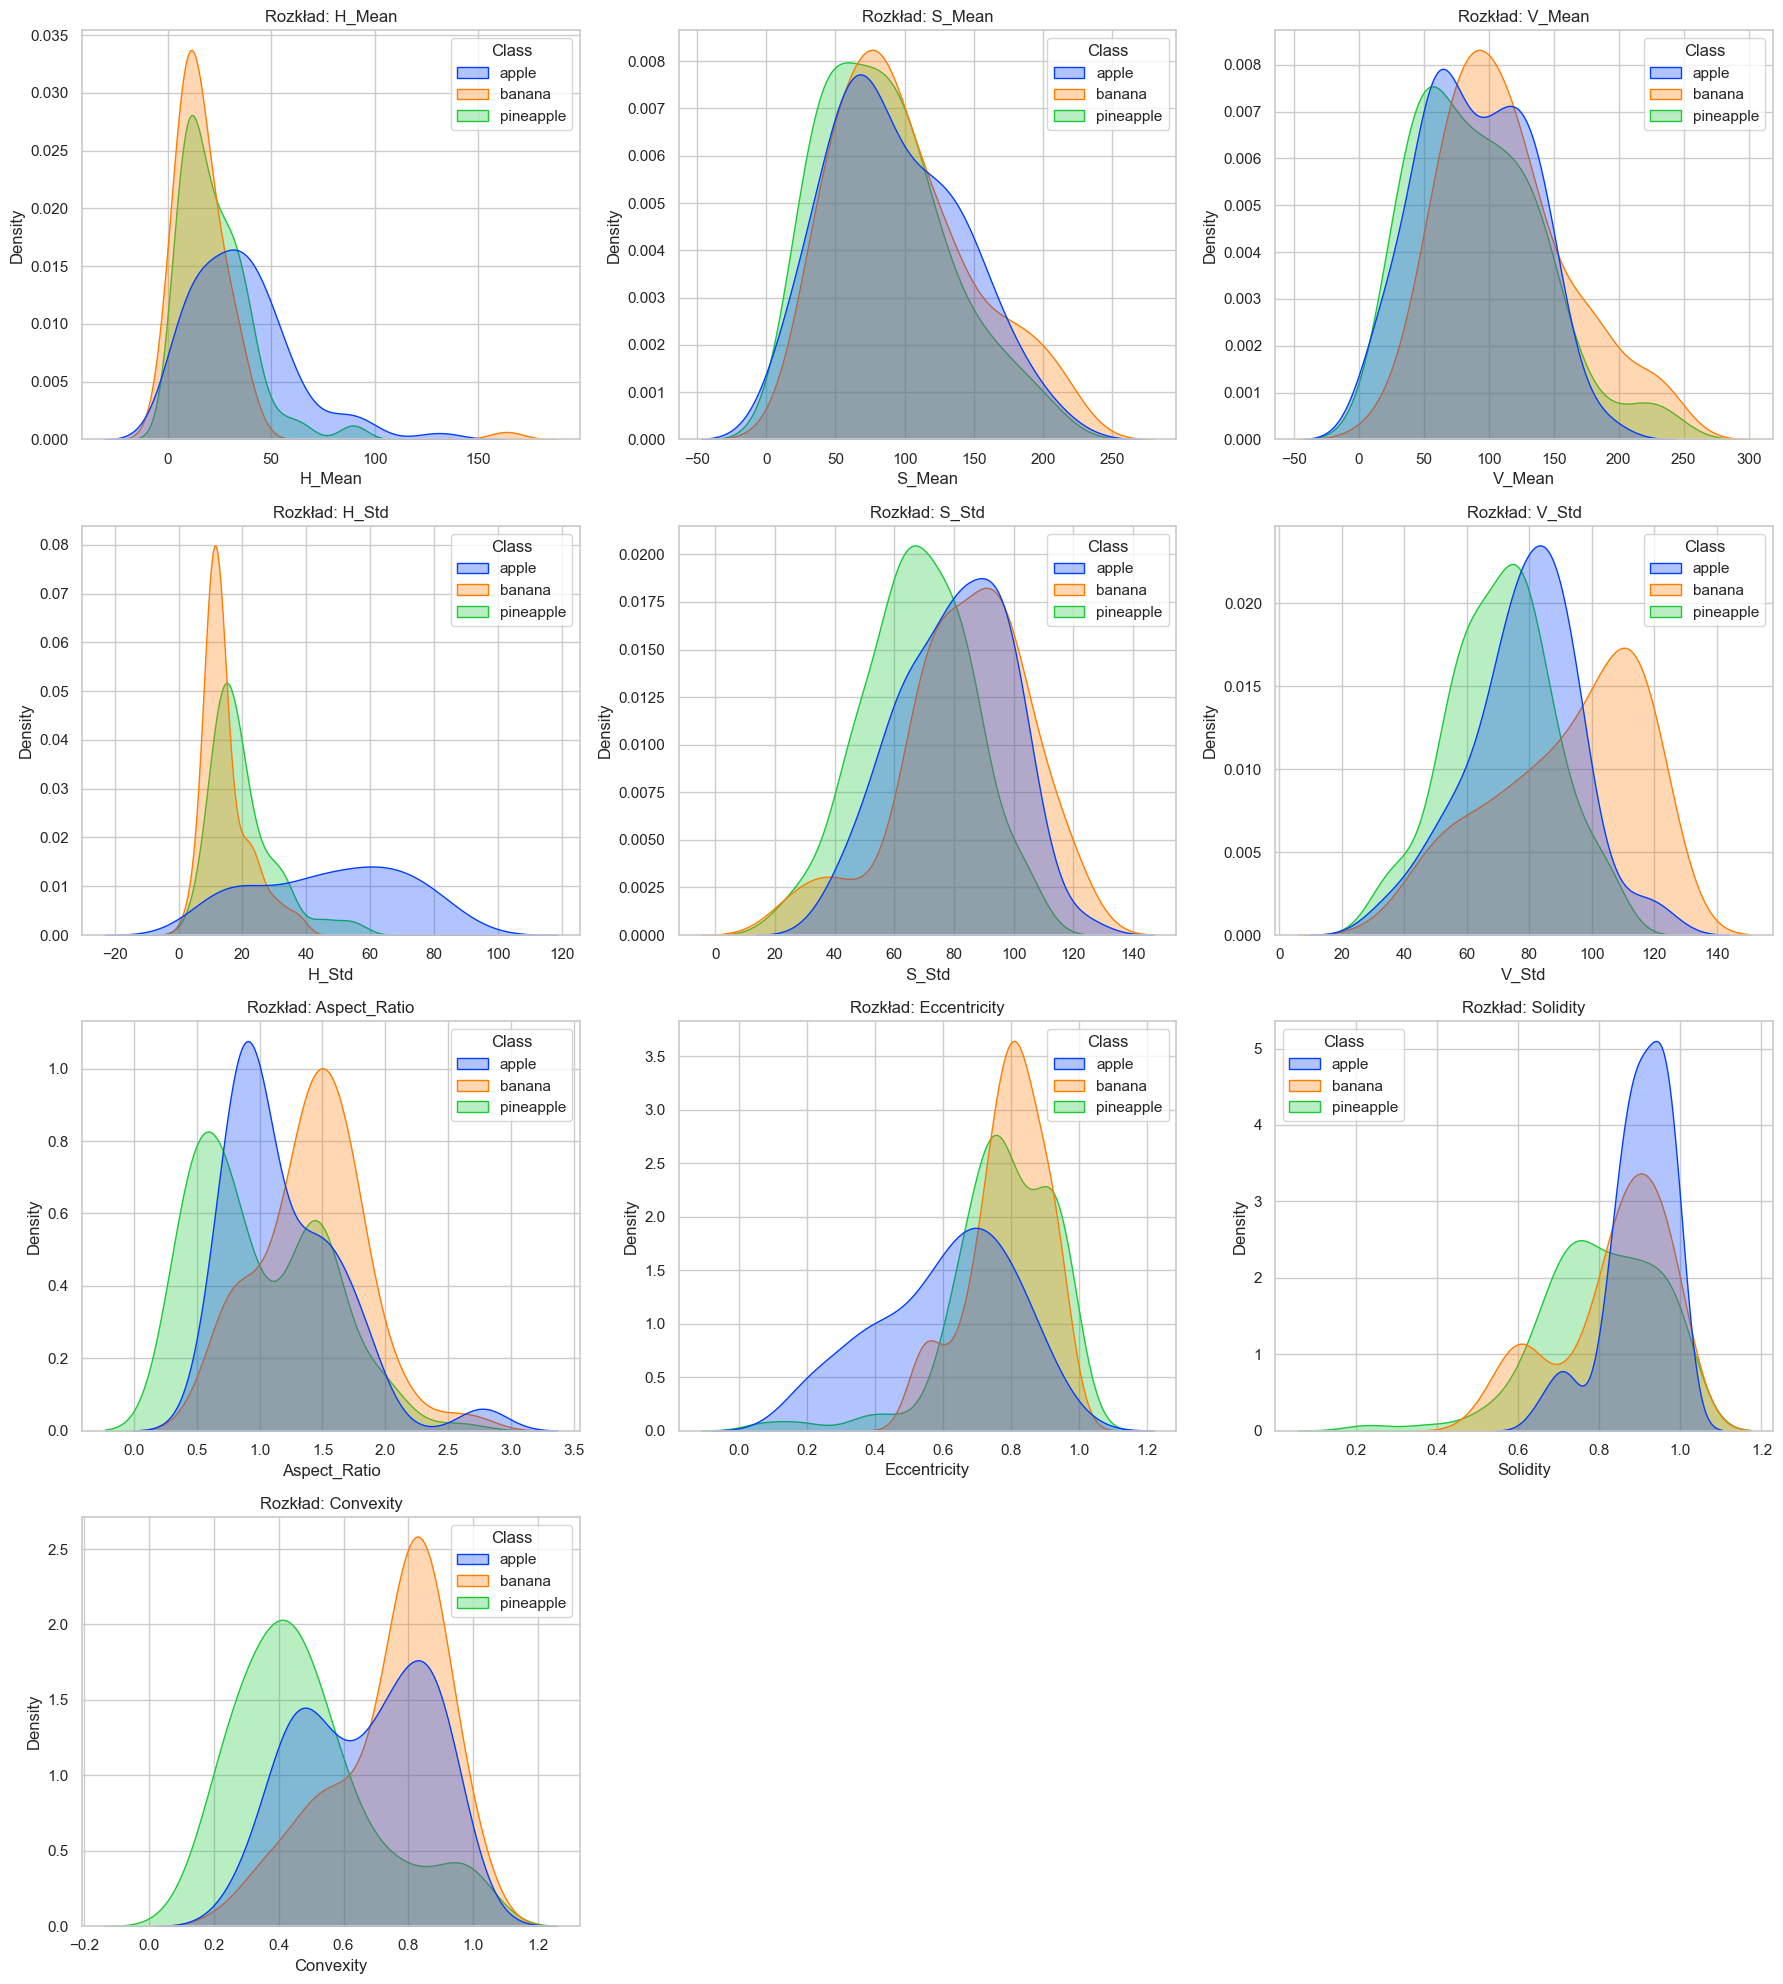

In [61]:
plot_feature_distributions(df_train)

### Wnioski:
#### Analiza cech kolorów:
- H_Mean - wyraźna widoczna różnica dla jabłek, których wariancja jest dużo mniejsza dla wyższych wartości Hue (Odcienia). Banany i ananasy pokrywają się w niższych wartościach.
- S_Mean - obrazy w dużej mierze pokrywają się pod kątem saturacji.
- V_Mean - banany mają najgęstszą wartość jasności wokół 100, jabłka mają ekstrema powyżej i poniżej 100, ananasy mają największą gęstość średniej jasności ok. 50.
- H_Std - jabłka mają bardzo szeroki rozkład wariancji H_std. Sugeruje to, że jabłka w zbiorze są wielokolorowe.
- S_Std - owoce w dużej mierze się pokrywają
- V_Std - banany mają wyraźnie wyższą zmienność jasności niż ananasy i jabłka.

#### Analiza cech kształtu:
- Aspect_ratio - widoczna różnica między owocami. Ananasy mają szaroki rozkład, lecz zwykle mają wartości 0.6 oraz 1.5 (zapewne ze względu na orientację), jabłka zwykle mają Aspect Ratio bliskie 1.0, banany najgęstsze blisko 1.5.
- Eccentricity - największe wartości miały banany bliskie 0.8 o największej gęstości, a jabłka miały szeroki rozkład po całym spektrum.
- Solidity - owoce w dużej mierze się pokrywają, co sprawia, że cecha niesie niewiele informacji klasyfikatorowi.
- Convexity - ananasy posiadały widocznie niższe wartości niż jabłka i banany, a banany najwyższe. Ze względu na nieregularną strukturę ananasów (liście, skóra), wartość jest widocznie inna niż bananów, przez co ten parametr ma wysokie znaczenie dla klasyfikatora.

#### Najważniejsze dyskryptory:
- H_Mean, H_Std, Aspect_Ratio, Convexity

## Pairplot dla najważniejszych cech
Według rankingu najważniejszych cech dla drzewa decyzyjnego, przedstawiono pairplot'y dla najważniejszych cech -  H_Std, Convexity, H_Mean, S_Mean, Eccentricity.

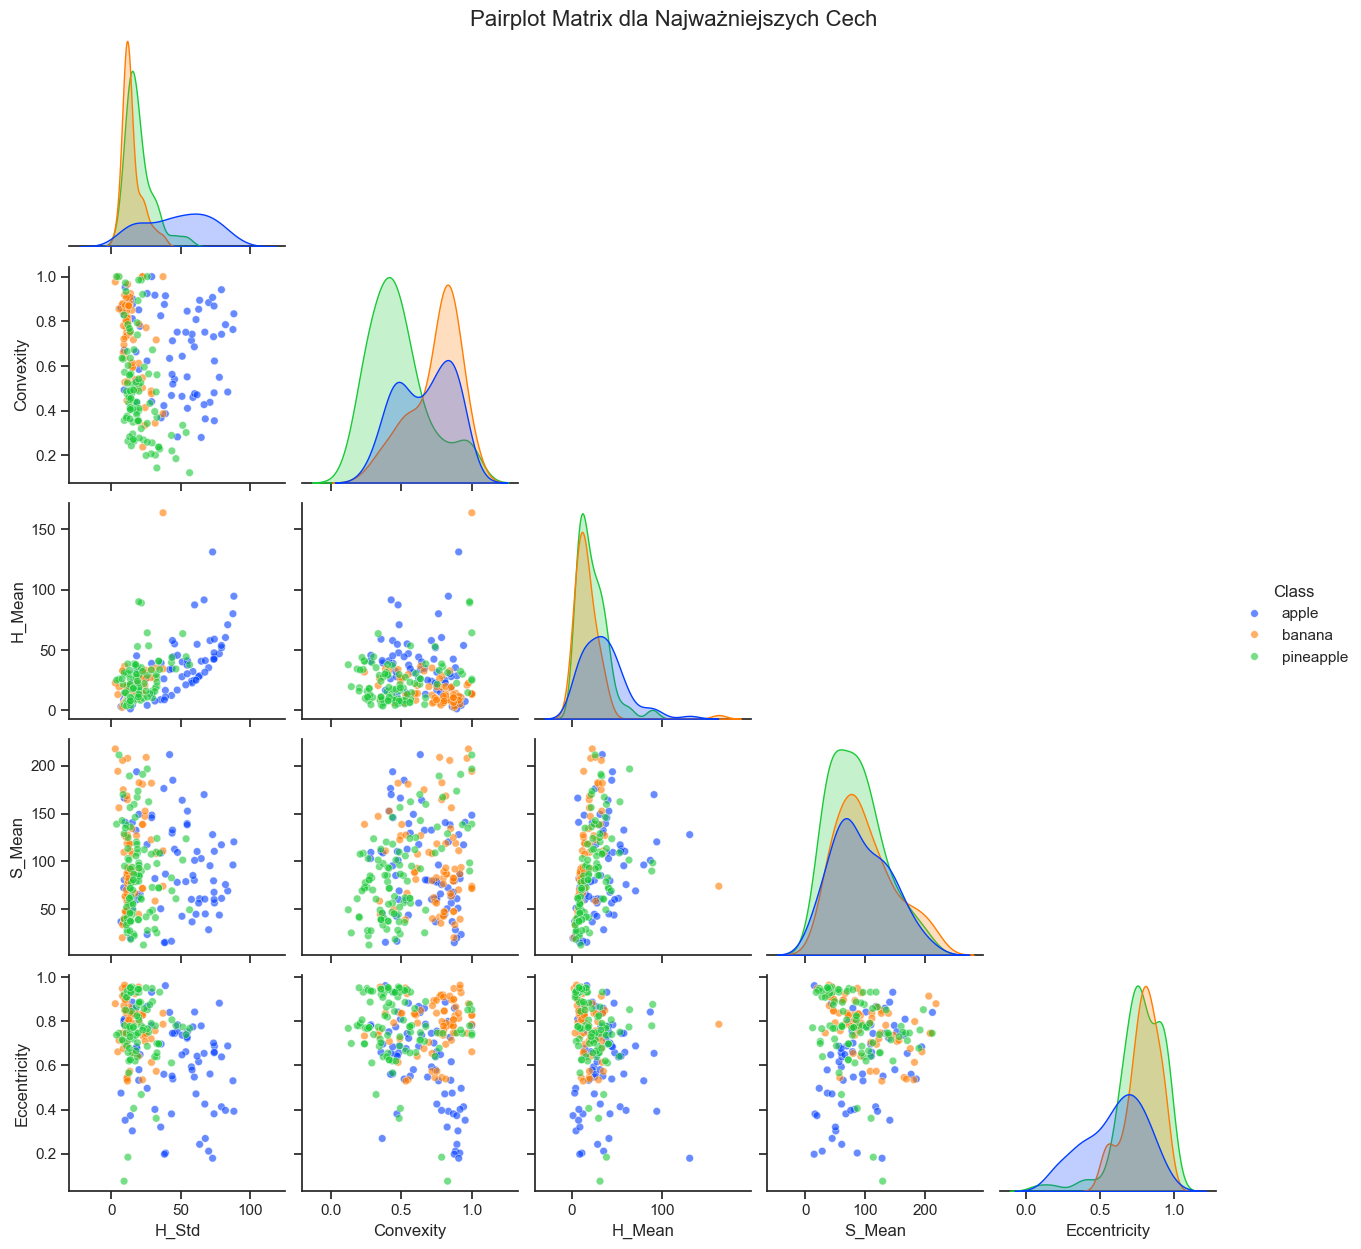

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Najważniejsze
columns_to_plot = ['H_Std', 'Convexity', 'H_Mean', 'S_Mean', 'Eccentricity', 'Class']

# Tworzymy podzbiór DataFrame tylko z wybranymi kolumnami
df_subset = df_train[columns_to_plot].copy()

# Wygląd wykresu
sns.set_theme(style="ticks")

# Tworzymy Pairplot
sns.pairplot(
    df_subset, 
    hue='Class',      # Kolorowanie punktów na podstawie klasy owocu
    palette='bright',
    corner=True,      # Tylko dolna część macierzy - górna to lustrzane odbicie
    diag_kind='kde',  # Na przekątnej rysujemy wykresy gęstości KDE
    plot_kws={'alpha': 0.6, 's': 30}, # Ustawienia dla punktów: przezroczystość i rozmiar
    diag_kws={'fill': True} # Ustawienia dla wykresów na przekątnej: wypełnienie kolorem
)

# Dodanie tytułu dla całego wykresu
plt.suptitle('Pairplot Matrix dla Najważniejszych Cech', y=1, fontsize=16)

plt.show()

### Wnioski:
Scatterplot - pokazuje relację miedzy dwiema cechami. Jeżeli punkty poszczególnych owoców są skupione w widocznie różnych punktach, oznacza to, że dana para cech jest dobrym deskryptorem przy klasyfikacji (np. Convexity/H_Std, H_Mean/H_Std, Eccentricity/H_Std). Jeżeli punkty różnych owoców nakładają sie w tym samym miejscu, oznacza to, że ta para tych dwóch cech jest słabym deskryptorem przy klasyfikacji.

- Dla jabłek, wszystkie pary z wariancją Hue (H_Std), wykazują się dużą separacją od reszty owoców. W szczególności widoczne jest to dla parametru "Convexity".
- Dla ananasów, szczególnie istotny jest parametr Convexity. Dla H_Mean, w dużej mierze pokrywa się z bananami.
- Dla bananów najbardziej istotne pary parametrów to Convexity-Eccentricity, oraz Convexity-H_Mean.

## Dyskusja wyników
Przeprowadzone eksperymenty pozwoliły na ocenę skuteczności systemu klasyfikacji opartego na algorytmie Drzewa Decyzyjnego (Decision Tree).

Interpretacja skuteczności:
- Analiza wykresów (KDE oraz Pairplot) wykazała, że jabłka posiadają unikalną charakterystykę w kanale barwy (H_Mean), co czyni je najłatwiejszymi do odseparowania.
- Największym wyzwaniem dla klasyfikatora jest rozróżnienie bananów i ananasów. Jak pokazała analiza scatterplotów, ich cechy kolorystyczne (H_Mean, S_Mean) częściowo się pokrywają (oba owoce mają dominantę żółci).
- Kluczową cechą pozwalającą na ich rozróżnienie okazała się wypukłość (Convexity) oraz Aspect Ratio. Drzewo decyzyjne skutecznie wykorzystało te progi odcięcia do separacji klas, co widać na wykresie ważności cech (Feature Importance).

Analiza błędów:
- Ewentualne pomyłki klasyfikatora między bananem a ananasem wynikają z ograniczeń prostych reguł decyzyjnych w przypadku nietypowych ujęć (np. pocięty ananas o innej wypukłości niż cały owoc).

## Podsumowanie i wnioski końcowe
Celem projektu było stworzenie systemu klasyfikacji owoców z wykorzystaniem klasycznych metod Computer Vision. Cel został zrealizowany przy użyciu Drzewa Decyzyjnego.

Główne wnioski:
1. Metoda segmentacji: Zastosowanie progowania w przestrzeni HSV (zamiast RGB) pozwoliło na skuteczne wyodrębnienie owoców z tła, niwelując wpływ cieni.
2. Dobór cech: Eksperyment wykazał, że hybrydowe podejście łączące cechy kolorystyczne (H_Mean) z cechami kształtu (Convexity, Aspect Ratio) jest niezbędne. Sam kolor byłby niewystarczający do rozróżnienia banana od ananasa.
3. Wydajność: Wybrany klasyfikator (Drzewo Decyzyjne) poradził sobie z zadaniem, oferując jednocześnie pełną interpretowalność wyników (możliwość prześledzenia reguł decyzyjnych), co jest przewagą nad bardziej złożonymi modelami typu "czarna skrzynka".

Możliwości rozwoju:
W przyszłości system można rozbudować o analizę tekstur (np. filtry Gabora), co pozwoliłoby jeszcze skuteczniej odróżniać chropowatą strukturę ananasa od gładkiej skórki banana.

## Bibliografia
1. Dokumentacja OpenCV (Feature Detection, Image Processing): https://docs.opencv.org/
2. Scikit-learn Documentation (Random Forest Classifier): https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
3. Dataset "Fruit and Vegetable Image Recognition": https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
4. Dokumentacja biblioteki Seaborn (Wizualizacja danych): https://seaborn.pydata.org/